# VectorFFT vs FFTW vs Intel MKL — Performance Comparison

Split-complex batched 1D FFT (double precision, single-threaded AVX2)

**Data source**: reads from `vfft_bench_results.csv` (auto-generated by `vfft_bench.exe`)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

In [32]:
import pandas as pd
import os

# Load CSV — try same directory first, then build/bin
csv_candidates = [
    'vfft_bench_results.csv',
    '../../build/bin/vfft_bench_results.csv',
    os.path.join(os.path.dirname(__file__), 'vfft_bench_results.csv') if '__file__' in dir() else None,
]

df = None
for path in csv_candidates:
    if path and os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Loaded {len(df)} rows from {path}')
        break

if df is None:
    raise FileNotFoundError('vfft_bench_results.csv not found. Run vfft_bench.exe first.')

# The CSV has columns: timestamp,N,K,wis_factors,wis_ns,heur_factors,heur_ns,fftw_ns,wis_speedup,heur_speedup
# For MKL builds: timestamp,N,K,wis_factors,wis_ns,,,fftw_ns,mkl_ns,vs_fftw,vs_mkl
# Normalize column names
df.columns = df.columns.str.strip()

# Use the latest timestamp if multiple runs exist
if 'timestamp' in df.columns:
    latest = df['timestamp'].max()
    df = df[df['timestamp'] == latest].copy()
    print(f'Using run: {latest} ({len(df)} entries)')

# Extract arrays
N_arr = df['N'].values.astype(float)
K_arr = df['K'].values.astype(float)

# Find the "ours" column (wis_ns or first numeric timing column)
if 'wis_ns' in df.columns:
    ours_ns = pd.to_numeric(df['wis_ns'], errors='coerce').values
else:
    ours_ns = pd.to_numeric(df.iloc[:, 4], errors='coerce').values

# FFTW and MKL columns
if 'fftw_ns' in df.columns:
    fftw_ns = pd.to_numeric(df['fftw_ns'], errors='coerce').values
elif df.shape[1] > 7:
    fftw_ns = pd.to_numeric(df.iloc[:, 7], errors='coerce').values
else:
    fftw_ns = np.full(len(df), np.nan)

if 'mkl_ns' in df.columns:
    mkl_ns = pd.to_numeric(df['mkl_ns'], errors='coerce').values
elif df.shape[1] > 8:
    mkl_ns = pd.to_numeric(df.iloc[:, 8], errors='coerce').values
else:
    mkl_ns = np.full(len(df), np.nan)

# Filter out NaN rows
valid = ~(np.isnan(ours_ns) | np.isnan(fftw_ns))
N_arr = N_arr[valid]
K_arr = K_arr[valid]
ours_ns = ours_ns[valid]
fftw_ns = fftw_ns[valid]
mkl_ns = mkl_ns[valid]

has_mkl = not np.all(np.isnan(mkl_ns))

# Throughput
data_bytes = 2.0 * N_arr * K_arr * 8
ours_gbs = data_bytes / ours_ns
fftw_gbs = data_bytes / fftw_ns
mkl_gbs = data_bytes / mkl_ns if has_mkl else np.zeros_like(ours_gbs)

def is_pow2(n):
    n = int(n)
    return n > 0 and (n & (n-1)) == 0

print(f'{len(N_arr)} valid test cases')
if has_mkl:
    print(f'MKL data available')
else:
    print(f'No MKL data (FFTW comparison only)')

Loaded 44 rows from vfft_bench_results.csv
Using run: 100000 (1 entries)


ValueError: could not convert string to float: '32x25x25x5'

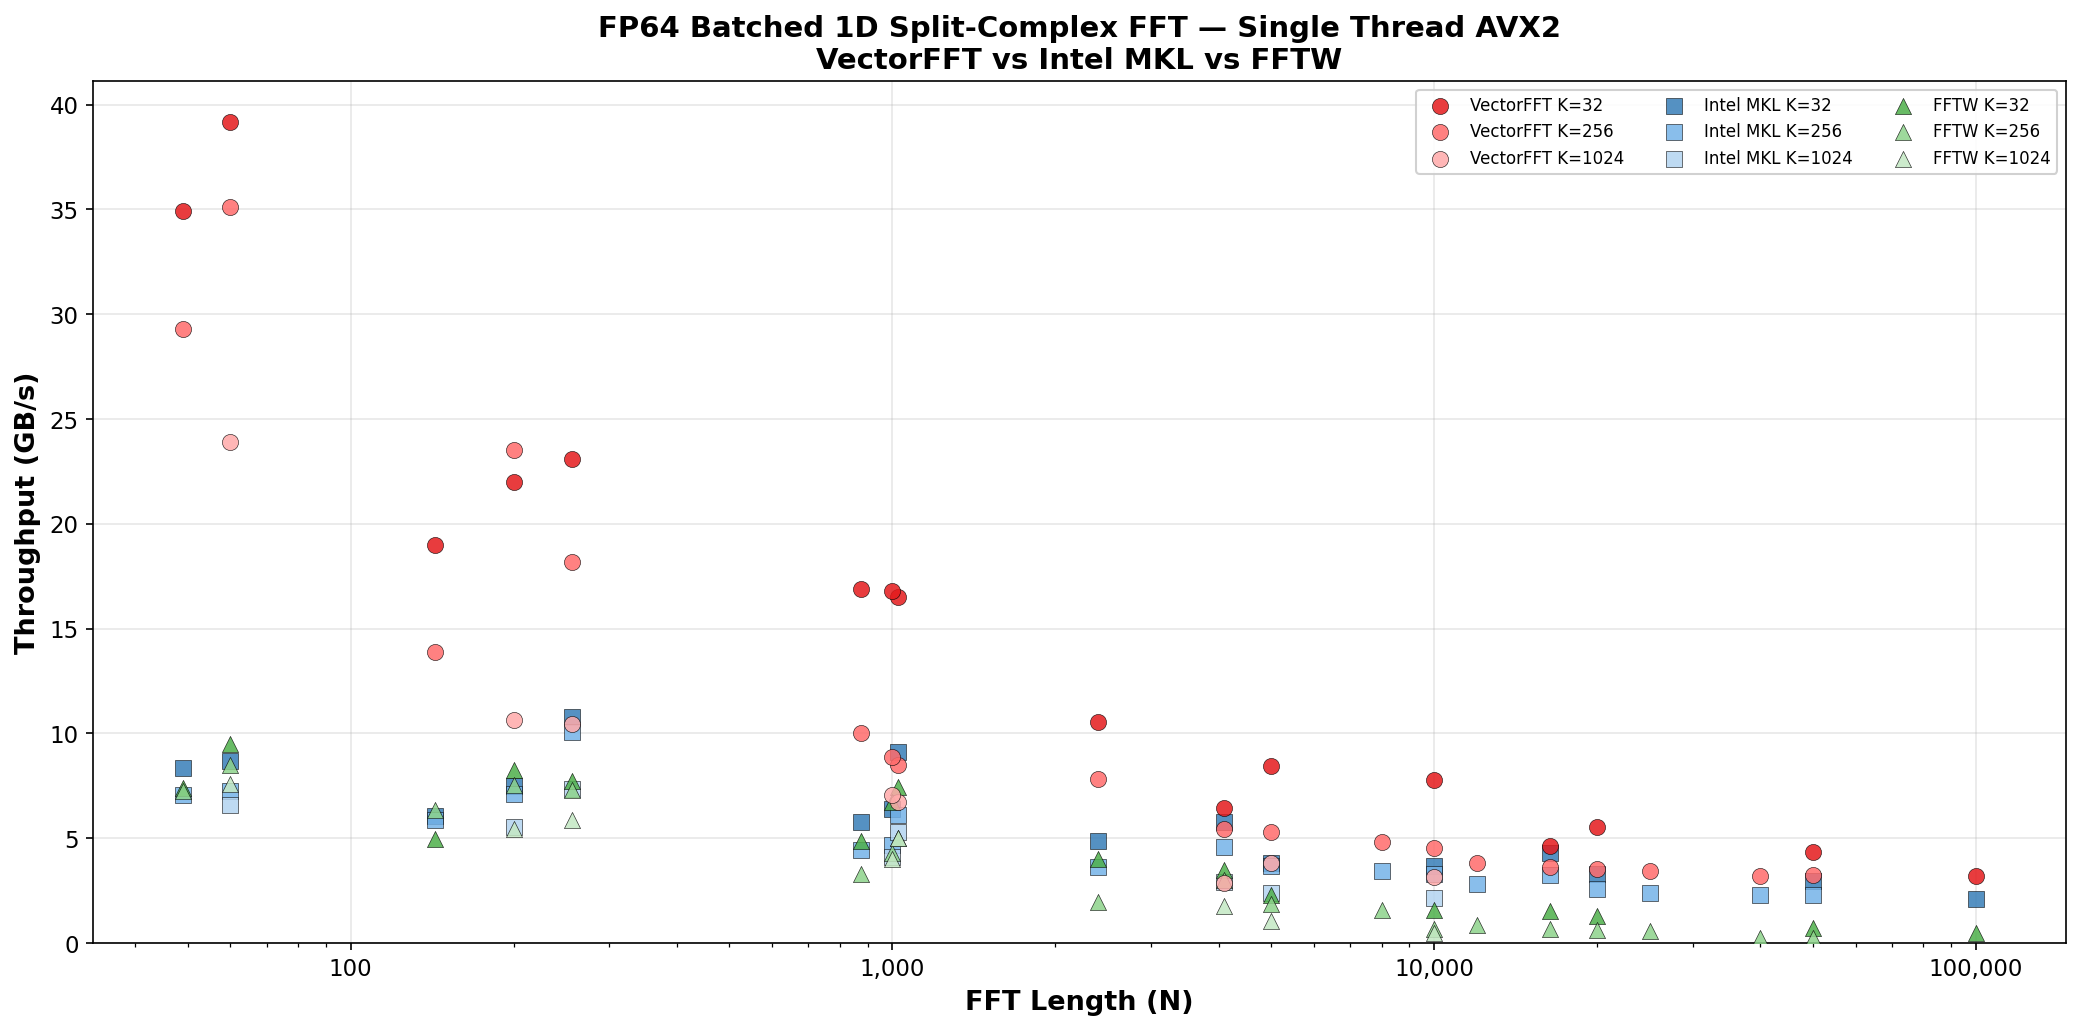

Saved: vfft_throughput.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Plot 1: Throughput (GB/s) vs FFT Length — VkFFT style
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

# Classify N values
def is_pow2(n):
    return n > 0 and (n & (n-1)) == 0

# Color by K
k_colors = {32: 0, 256: 1, 1024: 2}

for lib, gbs, marker, base_color, label_base in [
    ('ours', ours_gbs, 'o', ['#e41a1c', '#ff6b6b', '#ffaaaa'], 'VectorFFT'),
    ('mkl',  mkl_gbs,  's', ['#377eb8', '#74b3e8', '#b3d4f0'], 'Intel MKL'),
    ('fftw', fftw_gbs, '^', ['#4daf4a', '#8dd38b', '#c4e8c3'], 'FFTW'),
]:
    for ki, K_val in enumerate([32, 256, 1024]):
        mask = K_arr == K_val
        if not np.any(mask):
            continue
        ax.scatter(N_arr[mask], gbs[mask],
                   marker=marker, s=60, alpha=0.85,
                   color=base_color[ki], edgecolors='black', linewidth=0.3,
                   label=f'{label_base} K={K_val}' if ki == 0 or True else None,
                   zorder=5 if lib == 'ours' else 3)

ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Throughput (GB/s)', fontsize=13, fontweight='bold')
ax.set_title('FP64 Batched 1D Split-Complex FFT — Single Thread AVX2\n'
             'VectorFFT vs Intel MKL vs FFTW', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('vfft_throughput.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_throughput.png')

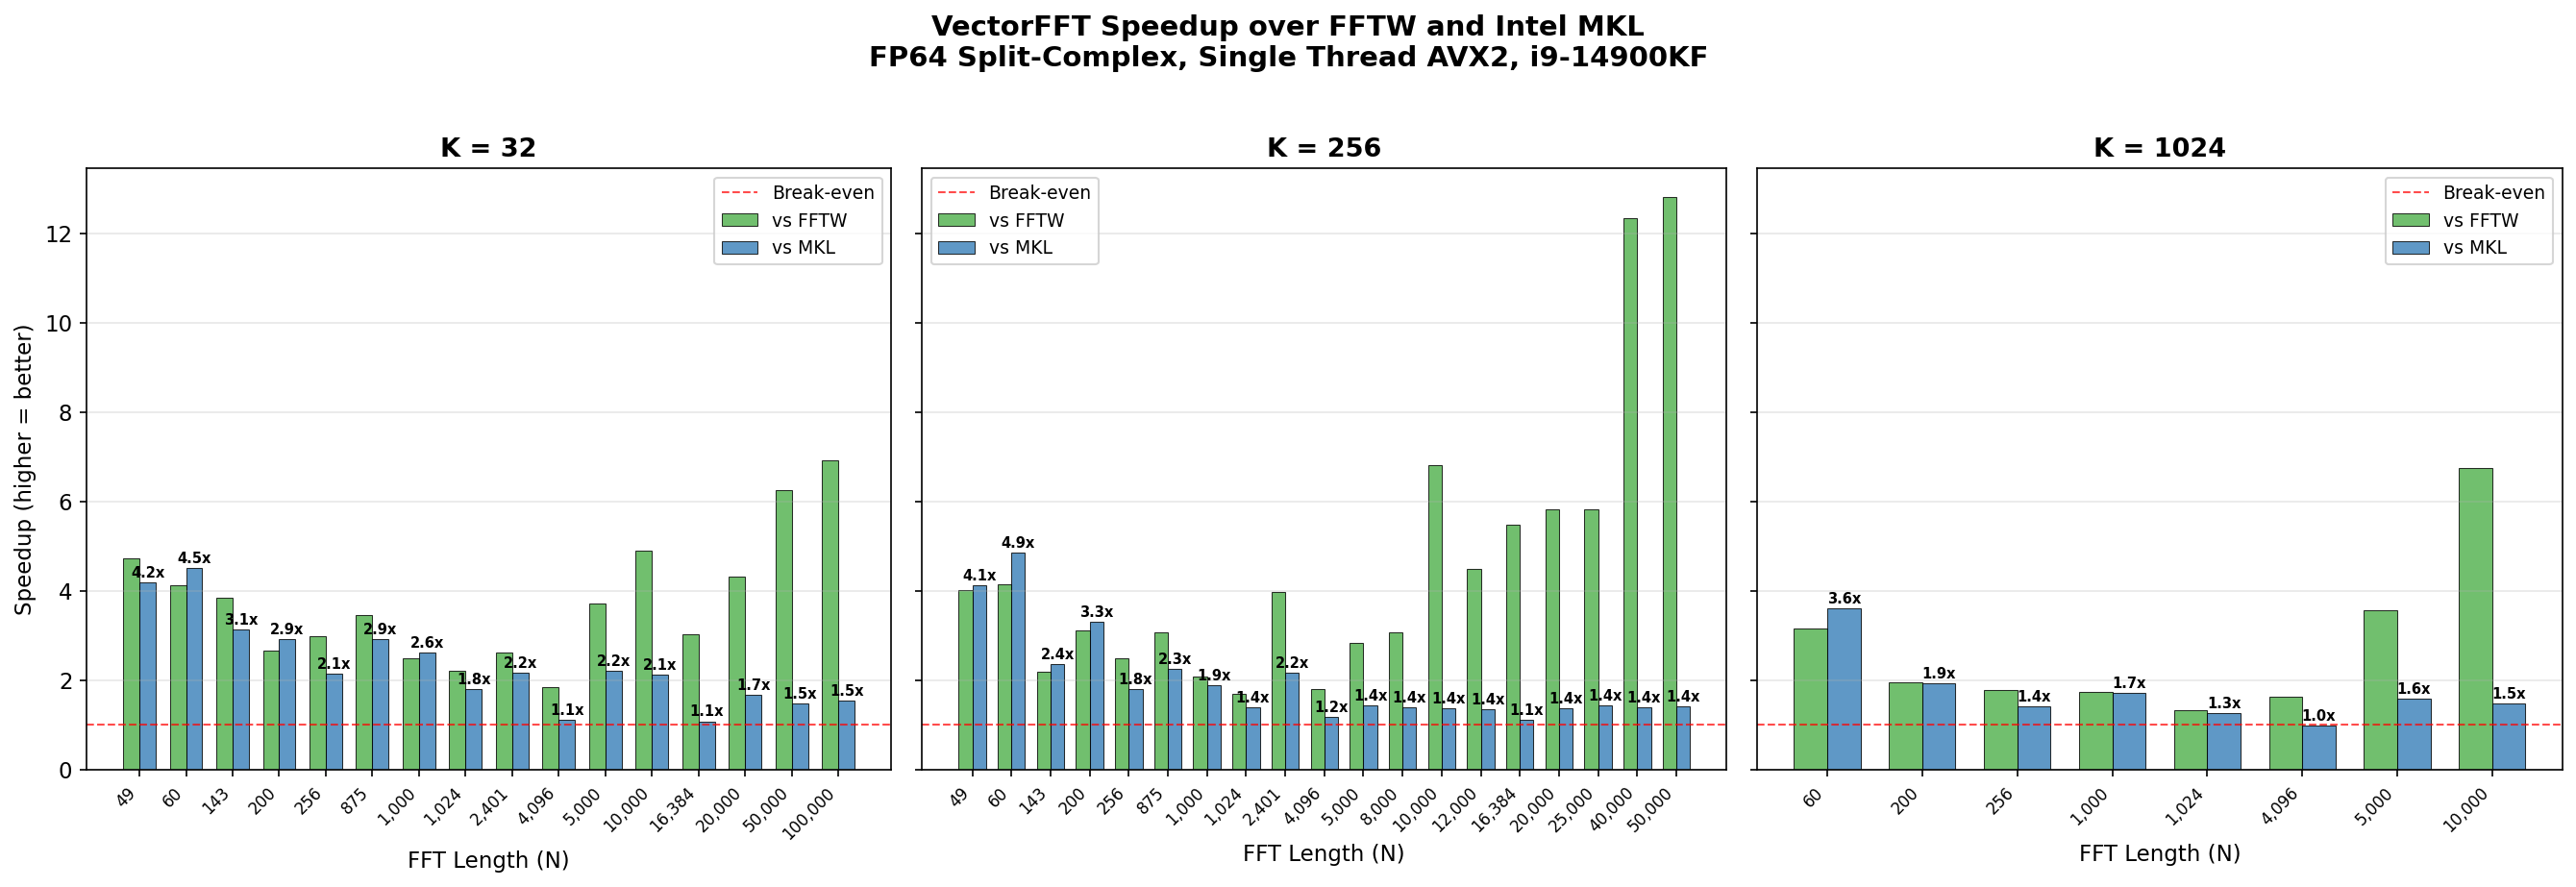

Saved: vfft_speedup_bars.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Plot 2: Speedup ratios vs N — grouped bar chart
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ki, K_val in enumerate([32, 256, 1024]):
    ax = axes[ki]
    mask = K_arr == K_val
    Ns = N_arr[mask]
    vs_fftw = fftw_ns[mask] / ours_ns[mask]
    vs_mkl  = mkl_ns[mask] / ours_ns[mask]

    # Sort by N
    order = np.argsort(Ns)
    Ns = Ns[order]
    vs_fftw = vs_fftw[order]
    vs_mkl = vs_mkl[order]

    x = np.arange(len(Ns))
    w = 0.35

    bars1 = ax.bar(x - w/2, vs_fftw, w, label='vs FFTW', color='#4daf4a', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + w/2, vs_mkl,  w, label='vs MKL',  color='#377eb8', alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Break-even')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(n):,}' for n in Ns], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'K = {K_val}', fontsize=13, fontweight='bold')
    ax.set_xlabel('FFT Length (N)', fontsize=11)
    if ki == 0:
        ax.set_ylabel('Speedup (higher = better)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars2, vs_mkl):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}x', ha='center', va='bottom', fontsize=7, fontweight='bold')

fig.suptitle('VectorFFT Speedup over FFTW and Intel MKL\n'
             'FP64 Split-Complex, Single Thread AVX2, i9-14900KF',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vfft_speedup_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_speedup_bars.png')

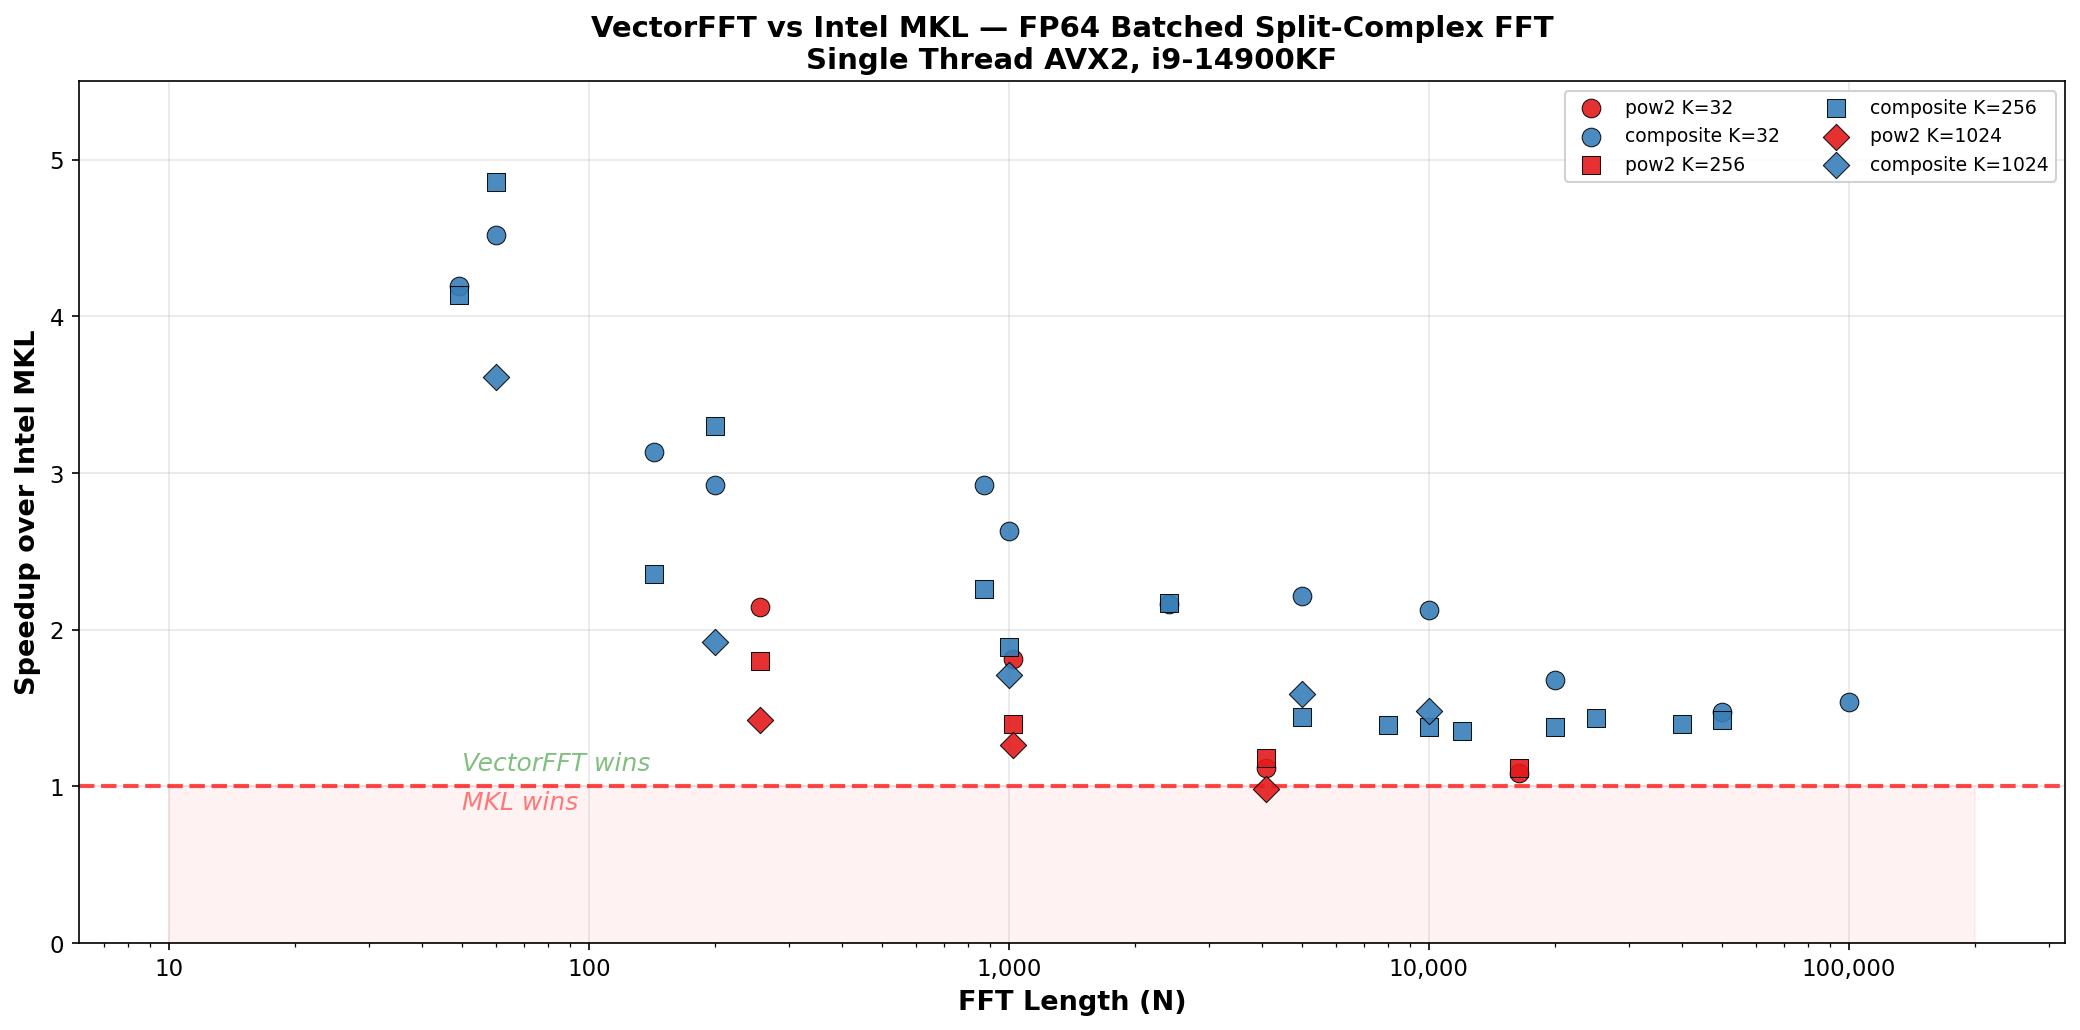

Saved: vfft_vs_mkl.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Plot 3: Speedup vs MKL as scatter — VkFFT style
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

vs_mkl_all = mkl_ns / ours_ns
vs_fftw_all = fftw_ns / ours_ns

# Classify points
pow2_mask = np.array([is_pow2(n) for n in N_arr])
composite_mask = ~pow2_mask

for K_val, marker, size in [(32, 'o', 80), (256, 's', 80), (1024, 'D', 80)]:
    mask = K_arr == K_val

    # Pow2
    m = mask & pow2_mask
    if np.any(m):
        ax.scatter(N_arr[m], vs_mkl_all[m], marker=marker, s=size,
                   color='#e41a1c', edgecolors='black', linewidth=0.5,
                   alpha=0.9, label=f'pow2 K={K_val}', zorder=5)

    # Composite
    m = mask & composite_mask
    if np.any(m):
        ax.scatter(N_arr[m], vs_mkl_all[m], marker=marker, s=size,
                   color='#377eb8', edgecolors='black', linewidth=0.5,
                   alpha=0.9, label=f'composite K={K_val}', zorder=5)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between([10, 200000], 0, 1, color='red', alpha=0.05)
ax.text(50, 0.85, 'MKL wins', fontsize=12, color='red', alpha=0.5, fontstyle='italic')
ax.text(50, 1.1, 'VectorFFT wins', fontsize=12, color='green', alpha=0.5, fontstyle='italic')

ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Speedup over Intel MKL', fontsize=13, fontweight='bold')
ax.set_title('VectorFFT vs Intel MKL — FP64 Batched Split-Complex FFT\n'
             'Single Thread AVX2, i9-14900KF', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 5.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.9)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('vfft_vs_mkl.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_vs_mkl.png')

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Summary statistics
# ═══════════════════════════════════════════════════════════════

vs_mkl_all = mkl_ns / ours_ns
vs_fftw_all = fftw_ns / ours_ns

print('VectorFFT vs Intel MKL:')
print(f'  Min:    {vs_mkl_all.min():.2f}x')
print(f'  Max:    {vs_mkl_all.max():.2f}x')
print(f'  Mean:   {vs_mkl_all.mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all):.2f}x')
print(f'  Wins:   {np.sum(vs_mkl_all > 1.0)}/{len(vs_mkl_all)}')
print()
print('VectorFFT vs FFTW:')
print(f'  Min:    {vs_fftw_all.min():.2f}x')
print(f'  Max:    {vs_fftw_all.max():.2f}x')
print(f'  Mean:   {vs_fftw_all.mean():.2f}x')
print(f'  Median: {np.median(vs_fftw_all):.2f}x')
print()
print('Composite N (not pow2) vs MKL:')
comp = np.array([not is_pow2(n) for n in N_arr])
print(f'  Mean:   {vs_mkl_all[comp].mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all[comp]):.2f}x')
print()
print('Pow2 N vs MKL:')
p2 = np.array([is_pow2(n) for n in N_arr])
print(f'  Mean:   {vs_mkl_all[p2].mean():.2f}x')
print(f'  Median: {np.median(vs_mkl_all[p2]):.2f}x')

VectorFFT vs Intel MKL:
  Min:    0.99x
  Max:    4.86x
  Mean:   2.08x
  Median: 1.71x
  Wins:   42/43

VectorFFT vs FFTW:
  Min:    1.34x
  Max:    12.82x
  Mean:   3.96x
  Median: 3.15x

Composite N (not pow2) vs MKL:
  Mean:   2.31x
  Median: 2.03x

Pow2 N vs MKL:
  Mean:   1.39x
  Median: 1.27x


In [ ]:
# Summary statistics (from CSV data)
vs_mkl_all = mkl_ns / ours_ns if has_mkl else np.array([])
vs_fftw_all = fftw_ns / ours_ns

print('VectorFFT vs FFTW:')
print(f'  Min:    {vs_fftw_all.min():.2f}x')
print(f'  Max:    {vs_fftw_all.max():.2f}x')
print(f'  Mean:   {vs_fftw_all.mean():.2f}x')
print(f'  Median: {np.median(vs_fftw_all):.2f}x')
print()

if has_mkl:
    print('VectorFFT vs Intel MKL:')
    print(f'  Min:    {vs_mkl_all.min():.2f}x')
    print(f'  Max:    {vs_mkl_all.max():.2f}x')
    print(f'  Mean:   {vs_mkl_all.mean():.2f}x')
    print(f'  Median: {np.median(vs_mkl_all):.2f}x')
    print(f'  Wins:   {np.sum(vs_mkl_all > 1.0)}/{len(vs_mkl_all)}')
    print()

    comp = np.array([not is_pow2(n) for n in N_arr])
    p2 = np.array([is_pow2(n) for n in N_arr])
    
    print('Composite N (not pow2) vs MKL:')
    if np.any(comp):
        print(f'  Mean:   {vs_mkl_all[comp].mean():.2f}x')
        print(f'  Median: {np.median(vs_mkl_all[comp]):.2f}x')
    print()
    print('Pow2 N vs MKL:')
    if np.any(p2):
        print(f'  Mean:   {vs_mkl_all[p2].mean():.2f}x')
        print(f'  Median: {np.median(vs_mkl_all[p2]):.2f}x')

# Per-case table
print('\n\nDetailed results:')
print(f'{"N":>6s} {"K":>4s} | {"ours_ns":>12s} {"fftw_ns":>12s} {"mkl_ns":>12s} | {"vs_fw":>6s} {"vs_mkl":>6s}')
print('-' * 70)
order = np.argsort(N_arr * 1e6 + K_arr)
for i in order:
    mkl_str = f'{mkl_ns[i]:12.0f}' if has_mkl and not np.isnan(mkl_ns[i]) else '         N/A'
    vs_mkl_str = f'{mkl_ns[i]/ours_ns[i]:6.2f}x' if has_mkl and not np.isnan(mkl_ns[i]) else '   N/A'
    print(f'{int(N_arr[i]):6d} {int(K_arr[i]):4d} | {ours_ns[i]:12.0f} {fftw_ns[i]:12.0f} {mkl_str} | {fftw_ns[i]/ours_ns[i]:6.2f}x {vs_mkl_str}')

NameError: name 'has_mkl' is not defined